# Predictive Maintenance — Multiclass Classification Pipeline

**Задача:** Определить тип отказа станка ЧПУ (классификация по 5 типам отказов)

**Архитектура (каскад):**
```
Входные данные
      │
      ▼
Binary Classifier  →  Норма (0)  →  Станок исправен
      │
   Отказ (1)
      │
      ▼
Multiclass Classifier  →  Тип отказа
```

**Типы отказов:**
- `TWF`  — Tool Wear Failure (отказ из-за износа инструмента)
- `HDF`  — Heat Dissipation Failure (отказ из-за теплоотдачи)
- `PWF`  — Power Failure (отказ из-за мощности)
- `OSF`  — Overstrain Failure (отказ из-за перегрузки)
- `RNF`  — Random Failure (случайный отказ)

**Этапы:**
1. EDA отказов — распределение типов, объём, дисбаланс
2. Feature Engineering (те же признаки что в бинарной задаче)
3. Подготовка данных (только строки с Target=1)
4. Train / Validation / Test split
5. Масштабирование
6. Работа с дисбалансом классов
7. Обучение моделей
8. GridSearchCV
9. Финальная оценка на Test
10. Сохранение модели

## Этап 1. EDA отказов

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('dataset/predictive_maintenance_clean.csv')

print(f'Загружено строк: {len(df_raw)}')
print(f'Столбцов: {len(df_raw.columns)}')
print(f'\nСтолбцы: {df_raw.columns.tolist()}')
df_raw.head(3)

Загружено строк: 9973
Столбцов: 10

Столбцы: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure


In [27]:
df_failures = df_raw[df_raw['Target'] == 1].copy()

print(f'Всего строк в датасете:   {len(df_raw)}')
print(f'Строк с отказами:          {len(df_failures)} ({len(df_failures)/len(df_raw)*100:.1f}%)')
print(f'\nВсе уникальные значения Failure Type (включая Target=0):')
print(df_raw['Failure Type'].value_counts().to_string())
print(f'\nРаспределение типов отказов (только Target=1):')
counts = df_failures['Failure Type'].value_counts()
for ftype, cnt in counts.items():
    print(f'  {ftype:<30} {cnt:>3} ({cnt/len(df_failures)*100:.1f}%)')

# Проверяем нет ли строк где Target=1, но Failure Type — нестандартный
mismatch = df_raw[(df_raw['Target'] == 1) & (df_raw['Failure Type'] == 'No Failure')]
print(f'\nАномалии (Target=1 но Failure Type=No Failure): {len(mismatch)}')

Всего строк в датасете:   9973
Строк с отказами:          330 (3.3%)

Все уникальные значения Failure Type (включая Target=0):
Failure Type
No Failure                  9643
Heat Dissipation Failure     112
Power Failure                 95
Overstrain Failure            78
Tool Wear Failure             45

Распределение типов отказов (только Target=1):
  Heat Dissipation Failure       112 (33.9%)
  Power Failure                   95 (28.8%)
  Overstrain Failure              78 (23.6%)
  Tool Wear Failure               45 (13.6%)

Аномалии (Target=1 но Failure Type=No Failure): 0


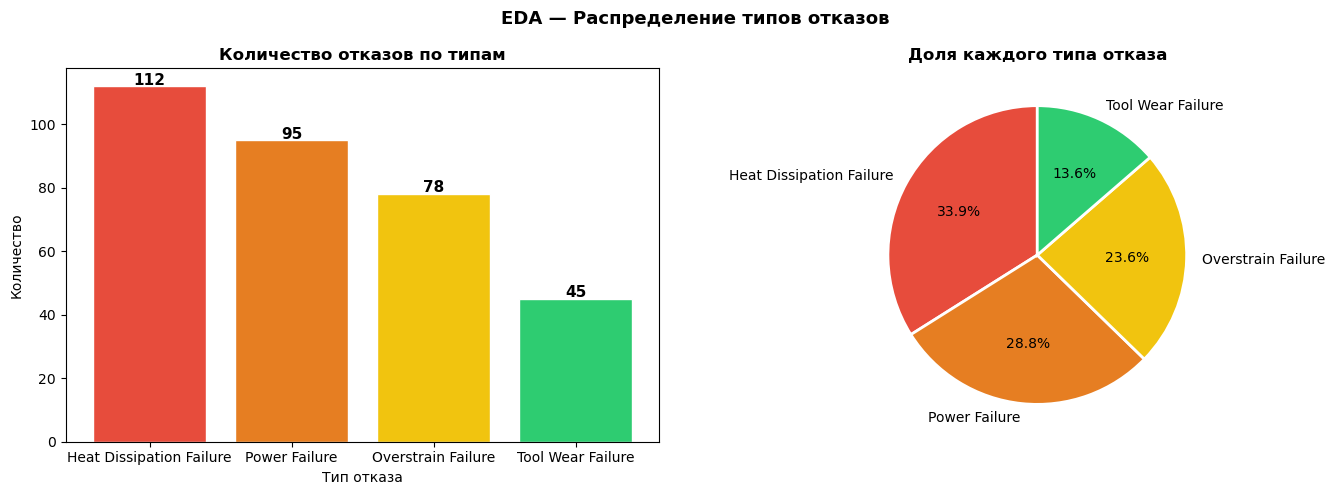

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Барплот количества по типам
counts = df_failures['Failure Type'].value_counts()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor='white')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.5, str(val),
                 ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Количество отказов по типам', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Количество')
axes[0].set_xlabel('Тип отказа')

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=counts.index,
    autopct='%1.1f%%', colors=colors,
    wedgeprops=dict(edgecolor='white', linewidth=2),
    startangle=90
)
for t in autotexts:
    t.set_fontsize(10)
axes[1].set_title('Доля каждого типа отказа', fontsize=12, fontweight='bold')

plt.suptitle('EDA — Распределение типов отказов', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

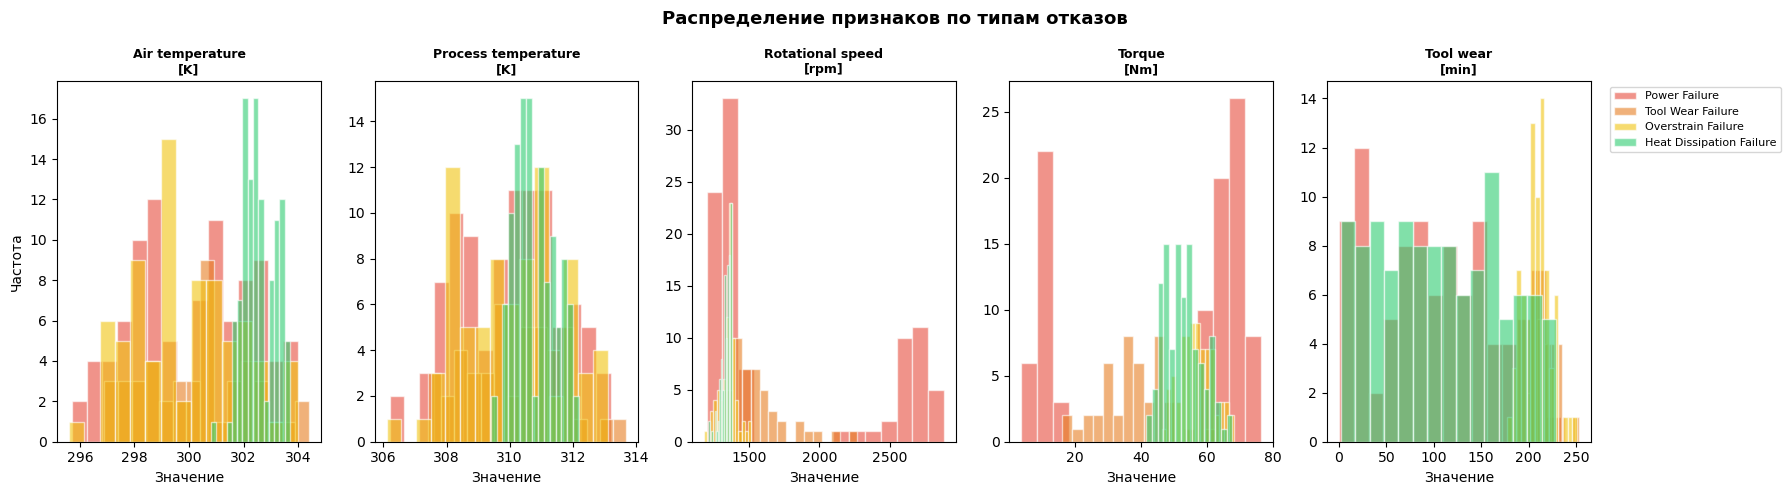

In [29]:
# Распределение числовых признаков по типам отказов
features_to_plot = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

failure_types = df_failures['Failure Type'].unique()
palette = dict(zip(failure_types, ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db']))

fig, axes = plt.subplots(1, len(features_to_plot), figsize=(18, 5))

for ax, feat in zip(axes, features_to_plot):
    for ftype, color in palette.items():
        subset = df_failures[df_failures['Failure Type'] == ftype][feat]
        ax.hist(subset, bins=15, alpha=0.6, color=color, label=ftype, edgecolor='white')
    ax.set_title(feat.replace(' [', '\n['), fontsize=9, fontweight='bold')
    ax.set_xlabel('Значение')

axes[0].set_ylabel('Частота')
axes[-1].legend(fontsize=8, bbox_to_anchor=(1.05, 1))

plt.suptitle('Распределение признаков по типам отказов', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Этап 2. Feature Engineering

In [30]:
# Те же три инженерных признака что и в бинарной задаче — физический смысл не меняется
df_raw['temp_diff']        = df_raw['Process temperature [K]'] - df_raw['Air temperature [K]']
df_raw['power']            = df_raw['Rotational speed [rpm]'] * df_raw['Torque [Nm]']
df_raw['tool_wear_torque'] = df_raw['Tool wear [min]'] * df_raw['Torque [Nm]']

print('Признаки созданы.')
print(df_raw[['temp_diff', 'power', 'tool_wear_torque']].describe().round(2))

Признаки созданы.
       temp_diff     power  tool_wear_torque
count     9973.0   9973.00           9973.00
mean        10.0  59958.79           4312.96
std          1.0  10189.30           2826.17
min          7.6  10966.80              0.00
25%          9.3  53111.00           1963.70
50%          9.8  59866.20           4006.80
75%         11.0  66859.00           6276.40
max         12.1  99980.40          16497.00


## Этап 3. Подготовка данных

In [31]:
# Оставляем только строки с отказами — мультиклассовая модель работает
# только когда бинарная модель уже предсказала "Отказ".
# Target (бинарный) больше не нужен — целевая переменная теперь Failure Type.

df = df_raw[df_raw['Target'] == 1].copy()

# Удаляем нерелевантные столбцы
cols_to_drop = [
    'UDI', 'Product ID', 'Target',
    'Air temperature [K]', 'Process temperature [K]'
]
df = df.drop(columns=cols_to_drop)

# One-Hot Encoding для типа продукта
df = pd.get_dummies(df, columns=['Type'], drop_first=True, dtype=int)

print(f'Строк для мультиклассовой задачи: {len(df)}')
print(f'Признаков: {df.shape[1] - 1}')
print(f'\nСтолбцы: {df.columns.tolist()}')
df.head(3)

Строк для мультиклассовой задачи: 330
Признаков: 8

Столбцы: ['Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Failure Type', 'temp_diff', 'power', 'tool_wear_torque', 'Type_L', 'Type_M']


,Rotational speed [rpm],Torque [Nm],Tool wear [min],Failure Type,temp_diff,power,tool_wear_torque,Type_L,Type_M
50,2861,4.6,143,Power Failure,10.2,13160.6,657.8,1,0
69,1410,65.7,191,Power Failure,10.1,92637.0,12548.7,1,0
77,1455,41.3,208,Tool Wear Failure,10.1,60091.5,8590.4,1,0


In [32]:
from sklearn.preprocessing import LabelEncoder

X = df.drop(columns=['Failure Type'])
y_raw = df['Failure Type']

# LabelEncoder: строковые метки → числа (0,1,2,3,4)
# Запоминаем маппинг — понадобится при интерпретации предсказаний в Web-приложении
le = LabelEncoder()
y = le.fit_transform(y_raw)

print('Маппинг классов (число → тип отказа):')
for i, cls in enumerate(le.classes_):
    cnt = (y == i).sum()
    print(f'  {i} → {cls:<30} ({cnt} примеров)')

Маппинг классов (число → тип отказа):
  0 → Heat Dissipation Failure       (112 примеров)
  1 → Overstrain Failure             (78 примеров)
  2 → Power Failure                  (95 примеров)
  3 → Tool Wear Failure              (45 примеров)


## Этап 4. Train / Validation / Test split

In [33]:
from sklearn.model_selection import train_test_split

# Та же схема что в бинарной задаче: 70% / 15% / 15%, stratify по классам
# Датасет маленький (~330 строк) — каждая строка на счету

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, stratify=y, random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=round(0.15 / 0.85, 4),
    stratify=y_temp,
    random_state=42
)

print(f'Train:      {X_train.shape[0]} строк ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Validation: {X_val.shape[0]} строк ({X_val.shape[0]/len(X)*100:.1f}%)')
print(f'Test:       {X_test.shape[0]} строк ({X_test.shape[0]/len(X)*100:.1f}%)')

print('\nРаспределение классов в каждой части:')
for name, y_part in [('Train', y_train), ('Validation', y_val), ('Test', y_test)]:
    print(f'\n  {name}:')
    for i, cls in enumerate(le.classes_):
        cnt = (y_part == i).sum()
        print(f'    {cls:<30} {cnt:>2}')

Train:      230 строк (69.7%)
Validation: 50 строк (15.2%)
Test:       50 строк (15.2%)

Распределение классов в каждой части:

  Train:
    Heat Dissipation Failure       78
    Overstrain Failure             54
    Power Failure                  67
    Tool Wear Failure              31

  Validation:
    Heat Dissipation Failure       17
    Overstrain Failure             12
    Power Failure                  14
    Tool Wear Failure               7

  Test:
    Heat Dissipation Failure       17
    Overstrain Failure             12
    Power Failure                  14
    Tool Wear Failure               7


## Этап 5. Обучение базовых моделей

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, classification_report

# Pipeline: StandardScaler → Classifier
# SMOTE здесь не нужен — дисбаланс 2.5:1 (112:45) умеренный.
# class_weight='balanced' автоматически взвешивает классы обратно пропорционально частоте.
#
# Три модели для сравнения:
#   LogisticRegression  — быстрый baseline
#   SVM RBF             — нелинейная граница, один-против-одного (OvO)
#   RandomForest        — ансамбль деревьев, хорошо работает на малых датасетах

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        ))
    ]),
    'SVM RBF': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    SVC(
            kernel='rbf',
            class_weight='balanced',
            probability=True,
            decision_function_shape='ovo',
            random_state=42
        ))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf',    RandomForestClassifier(
            class_weight='balanced',
            n_estimators=300,
            random_state=42
        ))
    ]),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    print(f'{name:<22} — обучена')

print('\nОценка на Validation:')
print(f'{"Модель":<22} {"F1 macro":>10} {"F1 weighted":>13}')
print('-' * 48)

results = {}
for name, model in models.items():
    y_pred = model.predict(X_val)
    f1_mac = f1_score(y_val, y_pred, average='macro')
    f1_wgt = f1_score(y_val, y_pred, average='weighted')
    results[name] = {'f1_macro': f1_mac, 'f1_weighted': f1_wgt}
    print(f'{name:<22} {f1_mac:>10.4f} {f1_wgt:>13.4f}')

print(f'\nЛучшая модель по F1 macro: {max(results, key=lambda x: results[x]["f1_macro"])}')

Logistic Regression    — обучена
SVM RBF                — обучена
Random Forest          — обучена

Оценка на Validation:
Модель                   F1 macro   F1 weighted
------------------------------------------------
Logistic Regression        0.9541        0.9595
SVM RBF                    0.9265        0.9393
Random Forest              1.0000        1.0000

Лучшая модель по F1 macro: Random Forest


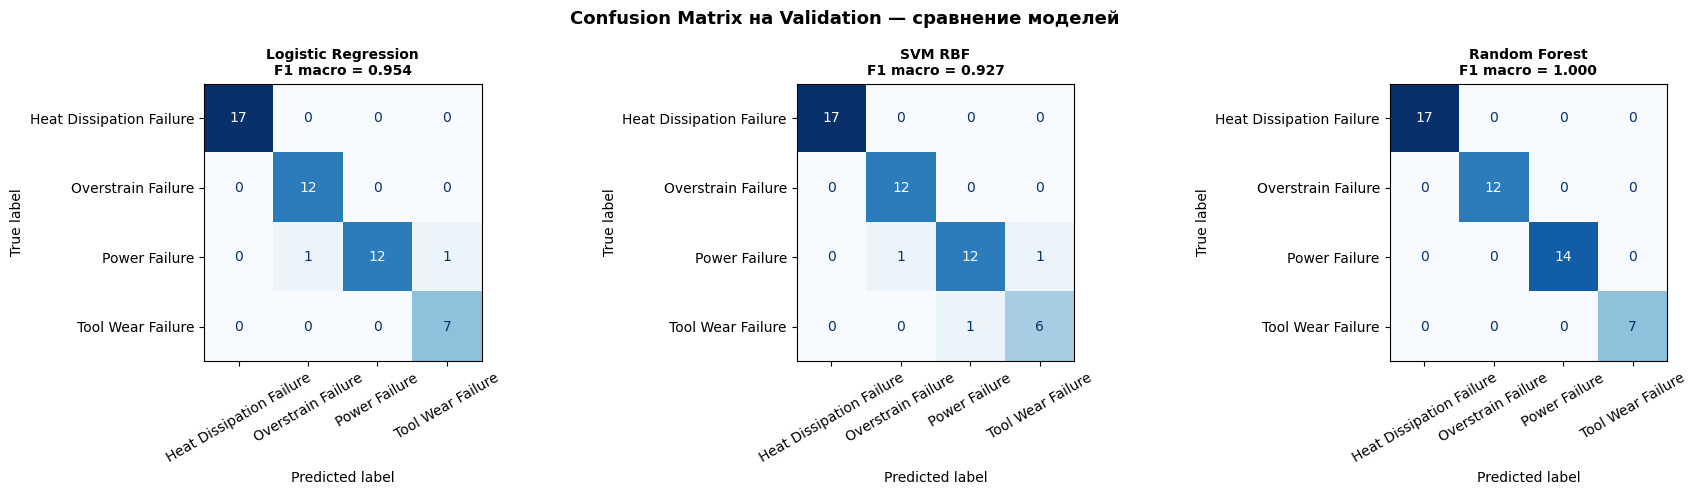

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix для каждой модели — смотрим какие типы путаются между собой
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
class_names = le.classes_

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=30)
    f1_mac = f1_score(y_val, y_pred, average='macro')
    ax.set_title(f'{name}\nF1 macro = {f1_mac:.3f}', fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrix на Validation — сравнение моделей', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Этап 6. cross_val_score

In [36]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# cross_val_score на train — проверяем стабильность.
# Датасет маленький (~231 train), поэтому CV особенно важен:
# одна случайная разбивка может дать завышенные/заниженные метрики.
#
# scoring='f1_macro' — среднее F1 по всем 4 классам без взвешивания по размеру.
# Это честная оценка: TWF (45 примеров) влияет столько же, сколько HDF (112).

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Модель":<22} {"F1 macro mean":>14} {"F1 macro std":>13}')
print('-' * 52)

cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='f1_macro')
    cv_results[name] = scores
    print(f'{name:<22} {scores.mean():>14.4f} {scores.std():>13.4f}')

print(f'\nЛучшая модель по CV F1 macro: {max(cv_results, key=lambda x: cv_results[x].mean())}')

Модель                  F1 macro mean  F1 macro std
----------------------------------------------------
Logistic Regression            0.8430        0.0227
SVM RBF                        0.8875        0.0198
Random Forest                  0.9575        0.0132

Лучшая модель по CV F1 macro: Random Forest


## Этап 7. GridSearchCV

In [37]:
from sklearn.model_selection import GridSearchCV

# GridSearch запускаем для двух лучших кандидатов: SVM и RandomForest.
# Параметры подбираем отдельно для каждой модели.
#
# Метрика: f1_macro — одинаково штрафует за ошибки на редком TWF и частом HDF.
# Это правильно: в production каждый тип отказа одинаково важно распознать.

# --- SVM ---
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    SVC(kernel='rbf', class_weight='balanced',
                  probability=True, decision_function_shape='ovo', random_state=42))
])

svm_param_grid = {
    'clf__C':     [0.1, 1, 10, 100],
    'clf__gamma': ['scale', 0.1, 0.01, 0.001],
}

svm_grid = GridSearchCV(
    svm_pipeline, svm_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, refit=True
)
svm_grid.fit(X_train, y_train)

print('=== SVM RBF ===')
print(f'Лучшие параметры: {svm_grid.best_params_}')
print(f'F1 macro (CV):    {svm_grid.best_score_:.4f}')

# --- Random Forest ---
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(class_weight='balanced', random_state=42))
])

rf_param_grid = {
    'clf__n_estimators': [100, 300, 500],
    'clf__max_depth':    [None, 5, 10, 20],
    'clf__min_samples_split': [2, 5, 10],
}

rf_grid = GridSearchCV(
    rf_pipeline, rf_param_grid,
    scoring='f1_macro',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, verbose=0, refit=True
)
rf_grid.fit(X_train, y_train)

print('\n=== Random Forest ===')
print(f'Лучшие параметры: {rf_grid.best_params_}')
print(f'F1 macro (CV):    {rf_grid.best_score_:.4f}')

# Выбираем лучшую модель
best_pipeline = svm_grid.best_estimator_ if svm_grid.best_score_ >= rf_grid.best_score_ else rf_grid.best_estimator_
best_name     = 'SVM RBF' if svm_grid.best_score_ >= rf_grid.best_score_ else 'Random Forest'
print(f'\nПобедитель: {best_name}')

=== SVM RBF ===
Лучшие параметры: {'clf__C': 100, 'clf__gamma': 0.1}
F1 macro (CV):    0.9503

=== Random Forest ===
Лучшие параметры: {'clf__max_depth': 5, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
F1 macro (CV):    0.9578

Победитель: Random Forest


## Этап 8. Финальная оценка на Test

   ФИНАЛЬНЫЕ МЕТРИКИ НА TEST — Random Forest
  F1 macro:    0.9708
  F1 weighted: 0.9796

                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      1.00      1.00        17
      Overstrain Failure       0.92      1.00      0.96        12
           Power Failure       1.00      1.00      1.00        14
       Tool Wear Failure       1.00      0.86      0.92         7

                accuracy                           0.98        50
               macro avg       0.98      0.96      0.97        50
            weighted avg       0.98      0.98      0.98        50



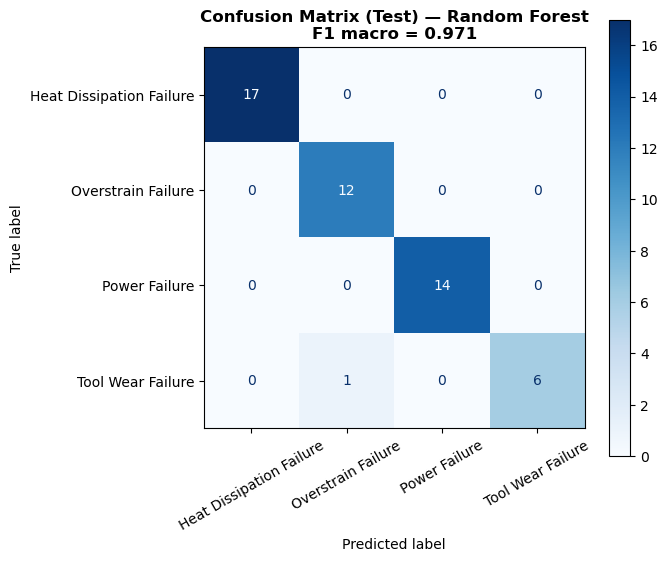

In [38]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score)
import matplotlib.pyplot as plt
import numpy as np

y_pred_test = best_pipeline.predict(X_test)

f1_mac = f1_score(y_test, y_pred_test, average='macro')
f1_wgt = f1_score(y_test, y_pred_test, average='weighted')

print("=" * 50)
print(f"   ФИНАЛЬНЫЕ МЕТРИКИ НА TEST — {best_name}")
print("=" * 50)
print(f"  F1 macro:    {f1_mac:.4f}")
print(f"  F1 weighted: {f1_wgt:.4f}")
print("=" * 50)
print()
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
ax.set_title(f'Confusion Matrix (Test) — {best_name}\nF1 macro = {f1_mac:.3f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Этап 9. Сохранение модели

In [39]:
import joblib
import os

# Сохраняем два объекта — всё что нужно Web-приложению:
#
#   pipeline       — sklearn.Pipeline (StandardScaler + Random Forest).
#                    Один вызов pipeline.predict(raw_data) → число класса (0-3).
#                    Никакого ручного масштабирования не нужно.
#
#   label_encoder  — LabelEncoder, обученный на Failure Type.
#                    Переводит число обратно в строку:
#                    label_encoder.inverse_transform([2]) → ['Power Failure']
#
# Threshold здесь не нужен — мультиклассовая модель возвращает argmax вероятностей,
# это уже встроено в predict().

os.makedirs('models', exist_ok=True)

model_bundle = {
    'pipeline':      best_pipeline,
    'label_encoder': le,
}

joblib.dump(model_bundle, 'models/multiclass_model.pkl')

# Проверка — загружаем обратно и делаем тестовое предсказание на сырых данных
loaded = joblib.load('models/multiclass_model.pkl')

pred_num  = loaded['pipeline'].predict(X_test.iloc[:5])
pred_name = loaded['label_encoder'].inverse_transform(pred_num)
true_name = loaded['label_encoder'].inverse_transform(y_test[:5])

size_kb = os.path.getsize('models/multiclass_model.pkl') / 1024

print(f"Файл сохранён: models/multiclass_model.pkl  ({size_kb:.1f} KB)")
print(f"\nСодержимое bundle:")
print(f"  pipeline:      {type(loaded['pipeline']).__name__}  "
      f"(шаги: {[s[0] for s in loaded['pipeline'].steps]})")
print(f"  label_encoder: {type(loaded['label_encoder']).__name__}  "
      f"(классы: {list(loaded['label_encoder'].classes_)})")
print(f"\nТестовое предсказание на 5 строках из test:")
for i, (pred, true) in enumerate(zip(pred_name, true_name)):
    status = '✓' if pred == true else '✗'
    print(f"  [{status}] Предсказано: {pred:<30}  Реально: {true}")
print(f"\nОбе модели готовы к деплою в Web-приложение.")
print(f"  Бинарная:      models/binary_model.pkl")
print(f"  Мультиклассовая: models/multiclass_model.pkl")

Файл сохранён: models/multiclass_model.pkl  (311.5 KB)

Содержимое bundle:
  pipeline:      Pipeline  (шаги: ['scaler', 'clf'])
  label_encoder: LabelEncoder  (классы: ['Heat Dissipation Failure', 'Overstrain Failure', 'Power Failure', 'Tool Wear Failure'])

Тестовое предсказание на 5 строках из test:
  [✓] Предсказано: Overstrain Failure              Реально: Overstrain Failure
  [✓] Предсказано: Power Failure                   Реально: Power Failure
  [✓] Предсказано: Power Failure                   Реально: Power Failure
  [✓] Предсказано: Power Failure                   Реально: Power Failure
  [✓] Предсказано: Heat Dissipation Failure        Реально: Heat Dissipation Failure

Обе модели готовы к деплою в Web-приложение.
  Бинарная:      models/binary_model.pkl
  Мультиклассовая: models/multiclass_model.pkl
